# Extensions originales

## Extension 1 : Combien de temps faut-il s'entrainer pour devenir stable ?

Dans cette section, nous voulons voir à partir de quel moment, l'explication devient stable (ReCo).

Nous allons donc entrainer un petit réseau sur un petit set de données (MNIST).

Nous allons ensuite tracer la courbe de la précision et de la stabilité en fonction des époques.


=== EXTENSION 1 ===
Démarrage de l'entraînement (5 époques)...


/home/thibault/.local/miniconda3/envs/rl/lib/python3.11/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(


Époque 1: Accuracy=68.2%, Instabilité (Lipschitz)=0.2882
Époque 2: Accuracy=88.1%, Instabilité (Lipschitz)=0.1048
Époque 3: Accuracy=91.4%, Instabilité (Lipschitz)=0.1469
Époque 4: Accuracy=92.4%, Instabilité (Lipschitz)=0.1478
Époque 5: Accuracy=95.1%, Instabilité (Lipschitz)=0.1557


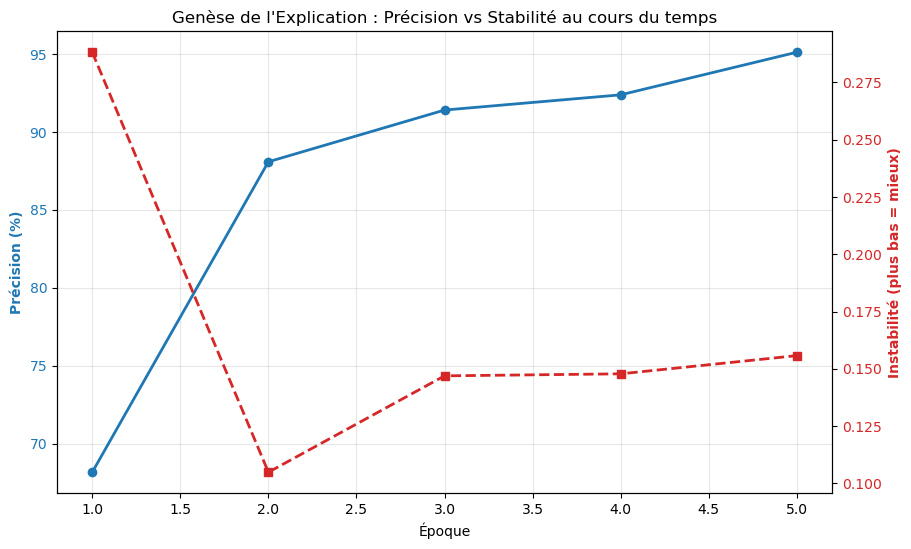

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from captum.attr import Saliency
import quantus
import numpy as np
import matplotlib.pyplot as plt

print("\n=== EXTENSION 1 ===")

# 1. Petit Modèle simple
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = torch.relu(torch.max_pool2d(self.conv1(x), 2))
        x = torch.relu(torch.max_pool2d(self.conv2(x), 2))
        x = x.view(-1, 320)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return torch.log_softmax(x, dim=1)

# 2. Préparation des données
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
# On limite le dataset pour que ça aille vite en démo
train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64)

model = SimpleCNN()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
criterion = nn.NLLLoss()

# 3. Encore la même fonction pour faire tourner Quantus
def explain_func(model, inputs, targets, **kwargs):
    # Quantus envoie du Numpy, Captum veut du PyTorch : on convertit !
    if isinstance(inputs, np.ndarray):
        inputs = torch.from_numpy(inputs).float().to(next(model.parameters()).device)
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets).long().to(next(model.parameters()).device)
        
    return Saliency(model).attribute(inputs, target=targets).detach().cpu().numpy()

# 4. Métrique de stabilité
metric_reco = quantus.LocalLipschitzEstimate(
    nr_samples=5, 
    perturb_std=0.1, 
    return_aggregate=True
)

history = {'epoch': [], 'accuracy': [], 'stability': []}

print("Démarrage de l'entraînement (5 époques)...")

for epoch in range(1, 6):
    # Train
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        if batch_idx > 100: break # On raccourcit l'époque pour la démo
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    
    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += len(data)
            if total > 500: break # On raccourcit le test
    acc = 100. * correct / total
    
    # On prend un petit lot d'images pour le test Quantus
    test_batch, test_target = next(iter(test_loader))
    test_batch, test_target = test_batch[:10], test_target[:10]
    
    # On calcule l'explication initiale pour a_batch (nécessaire pour certaines versions de Quantus)
    a_batch = explain_func(model, test_batch.numpy(), test_target.numpy())

    # Appel de la métrique avec explain_func
    reco_score = metric_reco(
        model=model, 
        x_batch=test_batch.numpy(), 
        y_batch=test_target.numpy(), 
        a_batch=a_batch, 
        explain_func=explain_func
    )
    
    # Calcul de la moyenne
    mean_stability = np.mean(reco_score)
    
    history['epoch'].append(epoch)
    history['accuracy'].append(acc)
    history['stability'].append(mean_stability)
    
    print(f"Époque {epoch}: Accuracy={acc:.1f}%, Instabilité (Lipschitz)={mean_stability:.4f}")

# 5. Affichage Graphique
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Époque')
ax1.set_ylabel('Précision (%)', color='tab:blue', fontweight='bold')
ax1.plot(history['epoch'], history['accuracy'], color='tab:blue', marker='o', linewidth=2, label='Précision')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('Instabilité (plus bas = mieux)', color='tab:red', fontweight='bold')
ax2.plot(history['epoch'], history['stability'], color='tab:red', marker='s', linestyle='--', linewidth=2, label='Instabilité')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Genèse de l'Explication : Précision vs Stabilité au cours du temps")
plt.show()

Conclusion : Le modèle devient plus stable lorsqu'il gagne en précision. Avec plus de puissance de calcul, sur de plus gros jeux de données, nous pourrions voir d'autres effets apparaître ?

Une stabilité qui évolue non linéairement, corrélé à la précision ? 

Découverte d'une stabilité qui serait sensible à de l'overfitting ?

## Extension 2 : Amélioration de la Fidélité ?

A travers cette extension nous allons essayer d'améliorer le score de fidélité d'une méthode d'interprétabilité. Pour ceci, nous avons pensé à faire la fusion de 3 méthodes : Saliency, Guided Backpropagation et Integrated Gradient.

L'idée serait de voir si nous obtenons un meilleur score lorsque nous fusionnons ces 3 méthodes.


=== EXTENSION 2 ===
1. Chargement Modèle + Image


/home/thibault/.local/miniconda3/envs/rl/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/thibault/.local/miniconda3/envs/rl/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


2. Génération des explications individuelles...


/home/thibault/.local/miniconda3/envs/rl/lib/python3.11/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/home/thibault/.local/miniconda3/envs/rl/lib/python3.11/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:64: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


3. Calcul de la Fusion...


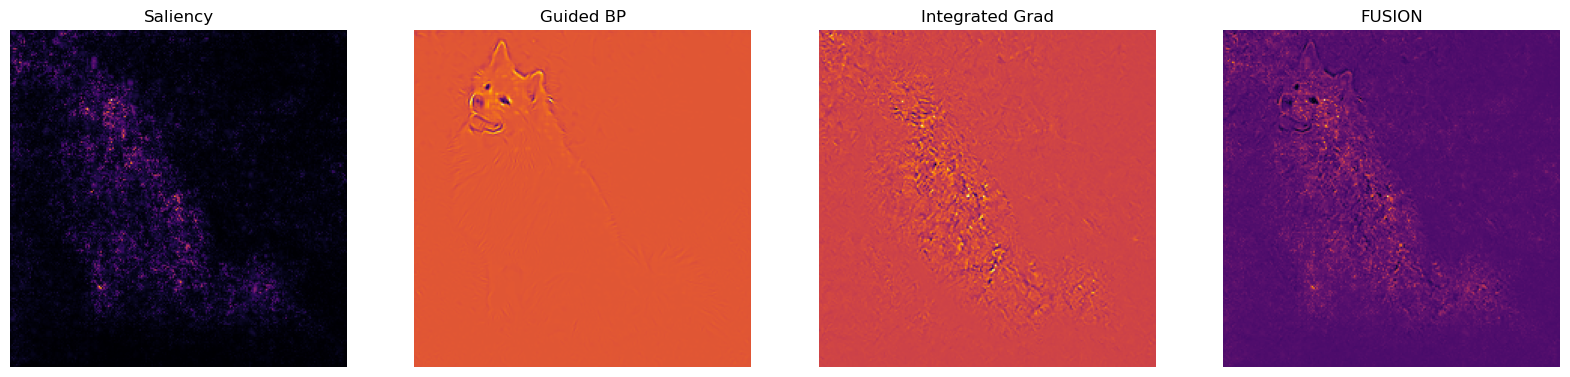

4. Évaluation avec Quantus...

--- Résultats ---
Score Fidélité (Saliency seule) : 0.0706
Score Fidélité (FUSION)         : 0.6055


In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from captum.attr import Saliency, GuidedBackprop, IntegratedGradients
import quantus
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

print("\n=== EXTENSION 2 ===")
print("1. Chargement Modèle + Image")

# 1. Setup
# Chargement du modèle
model = models.resnet50(pretrained=True)
model.eval()

# Chargement de l'image (Chien)
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(img).unsqueeze(0)

# Prédiction
output = model(input_tensor)
prediction_score, pred_label_idx = torch.topk(output, 1)

# 2. Génération des 3 cartes
print("2. Génération des explications individuelles...")

# Saliency
sal = Saliency(model).attribute(input_tensor, target=pred_label_idx)
# Guided Backprop
gbp = GuidedBackprop(model).attribute(input_tensor, target=pred_label_idx)
# Integrated Gradients (peut être long)
ig = IntegratedGradients(model).attribute(input_tensor, target=pred_label_idx, n_steps=20)

# 3. Fusion
print("3. Calcul de la Fusion...")

# Fonction de normalisation (0 à 1) pour pouvoir additionner proprement
def norm(attr):
    # On passe de (1, 3, 224, 224) à (224, 224) en sommant les canaux
    a = attr.detach().cpu().numpy().squeeze().transpose(1, 2, 0).sum(axis=2)
    return (a - a.min()) / (a.max() - a.min() + 1e-8)

m_sal = norm(sal)
m_gbp = norm(gbp)
m_ig = norm(ig)

# Moyenne des 3
m_fusion = (m_sal + m_gbp + m_ig) / 3.0

# 4. Visualisation
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
titles = ["Saliency", "Guided BP", "Integrated Grad", "FUSION"]
maps = [m_sal, m_gbp, m_ig, m_fusion]

for i in range(4):
    ax[i].imshow(maps[i], cmap='inferno')
    ax[i].set_title(titles[i])
    ax[i].axis('off')
plt.show()

# 5. Evaluation par Quantus ---
print("4. Évaluation avec Quantus...")

# On compare la fidélité de Saliency vs Fusion
# Plus le score est haut, mieux c'est.
metric_fid = quantus.FaithfulnessCorrelation(
    perturb_baseline="black", 
    nr_runs=10, 
    return_aggregate=True
)

# Préparation des données pour Quantus
x_b = input_tensor.detach().numpy()
y_b = np.array([pred_label_idx.item()])

# Score Saliency
# On remet au format (1, 3, 224, 224) que Quantus aime bien
score_sal = metric_fid(model=model, x_batch=x_b, y_batch=y_b, a_batch=sal.detach().numpy())

# Score Fusion
# La fusion est en 2D (224, 224), il faut la remettre en format "Batch PyTorch" (1, 3, 224, 224)
fusion_tensor = torch.tensor(m_fusion).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1).numpy()

score_fusion = metric_fid(model=model, x_batch=x_b, y_batch=y_b, a_batch=fusion_tensor)

print("\n--- Résultats ---")
print(f"Score Fidélité (Saliency seule) : {np.mean(score_sal):.4f}")
print(f"Score Fidélité (FUSION)         : {np.mean(score_fusion):.4f}")


Les résultats que nous obtenons sont plutôt mitigés. Il ne semble pas y avoir une vraie progression dans le score de fidélité. 

On retombe dans le papier d'Adebayo. On aurait tendance à penser que de supperposer les méthodes permettrait de mieux voir la forme (ici du chien) et donc d'améliorer le score de fidélité. En réalité, ces maps de chaleur sont trompeuses, pour l'oeil humain elles fonctionnent mais elles ne réprésentent pas vraiment ce que le réseau (Resnet) comprend/fait.

## Extension 3 : Et la robustness à la rotation ?

Nous avons maintenant voulu tester si les métriques d'interprétabilité sont robustes à la rotation. 

Pour cela nous avons tourné une image, et nous avons comparé 2 expériences.

Nous utilisons la méthode de Saliency car c'est avec elle que le résultat est le plus flagrant.

Première méthode : nous avons demandé un explication puis nous avons tourné la map de chaleur. La deuxième, nous avons fait l'inverse, nous avons tourné l'image puis demandé une explication. Enfin nous avons calculé la corrélation entre les 2 maps de chaleur pour déterminer si l'explication est robuste à une rotation.



 EXTENSION 3


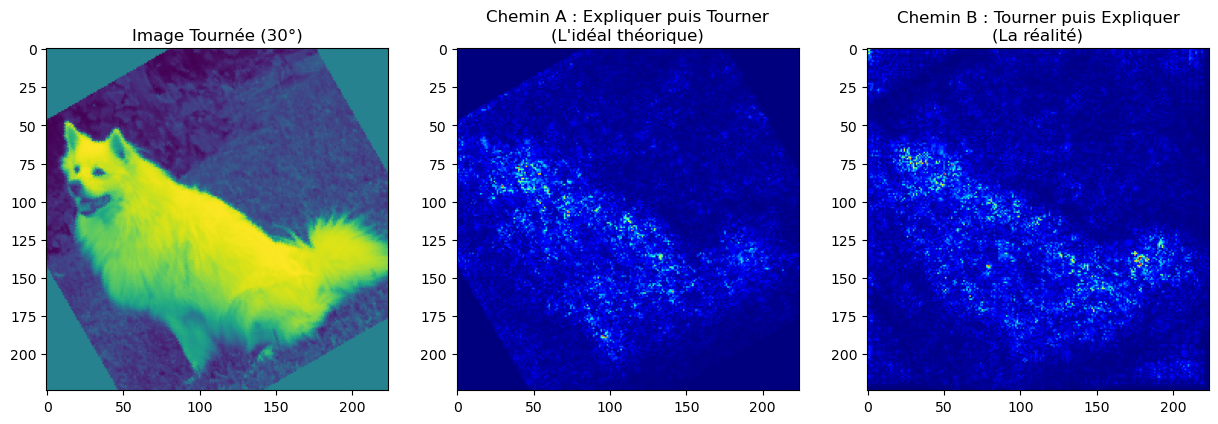

Corrélation entre les deux : 0.405


In [3]:
import torchvision.transforms.functional as TF
import torch.nn.functional as F

print("\n EXTENSION 3")

# 1. Rotation de l'image
angle = 30
img_rotated = TF.rotate(input_tensor, angle)

# 2. Demande des explications
saliency = Saliency(model)

# 1ère méthode
attr_original = saliency.attribute(input_tensor, target=pred_label_idx)
map_path_A = TF.rotate(attr_original, angle)

# 2ème méthode
out_rot = model(img_rotated)
pred_rot = out_rot.argmax(dim=1)
attr_rotated = saliency.attribute(img_rotated, target=pred_rot)
map_path_B = attr_rotated 

# 3. Visualisation
# Conversion pour affichage
def to_img(t): return t.squeeze().detach().cpu().numpy().transpose(1, 2, 0).sum(axis=2)

mA = to_img(map_path_A)
mB = to_img(map_path_B)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(to_img(img_rotated))
ax[0].set_title(f"Image Tournée ({angle}°)")

ax[1].imshow(mA, cmap='jet')
ax[1].set_title("Chemin A : Expliquer puis Tourner\n(L'idéal théorique)")

ax[2].imshow(mB, cmap='jet')
ax[2].set_title("Chemin B : Tourner puis Expliquer\n(La réalité)")
plt.show()

# 4. Mesure de la corrélation
correlation = np.corrcoef(mA.flatten(), mB.flatten())[0, 1]

print(f"Corrélation entre les deux : {correlation:.3f}")

On observe en général une corrélation entre les 2 méthodes aux alentours de 0.4. Ce résultat montre que la méthode de Saliency map n'est pas robuste à la rotation.

Nous pouvons donc penser à une autre métrique de robustness qui serait sujet à la rotation. On pourrait ainsi comparer les méthodes d'explicabilité (Grad Cam, Integrated Gradient, Gradient-Input...)